In [1]:
import os

data_dir = 'renders/synthetic_data_pitch_sweep'

for folder in ['rgb', 'ground_truth', 'uv', 'border']:
    folder_path = os.path.join(data_dir, folder)
    files = os.listdir(folder_path)
    print(f"{folder}: {len(files)} files, e.g. {files[0]}")

rgb: 2486 files, e.g. Gemini_Generated_Image_f1ghbxf1ghbxf1gh_paper_Final Project-35_P6_R0_A06.jpg
ground_truth: 2486 files, e.g. Gemini_Generated_Image_ea83igea83igea83_paper_Final Project-44_P3_R0_A09.png
uv: 2486 files, e.g. Gemini_Generated_Image_ea83igea83igea83_paper_Final Project-44_P3_R0_A09.png
border: 2486 files, e.g. Gemini_Generated_Image_ea83igea83igea83_paper_Final Project-44_P3_R0_A09.png


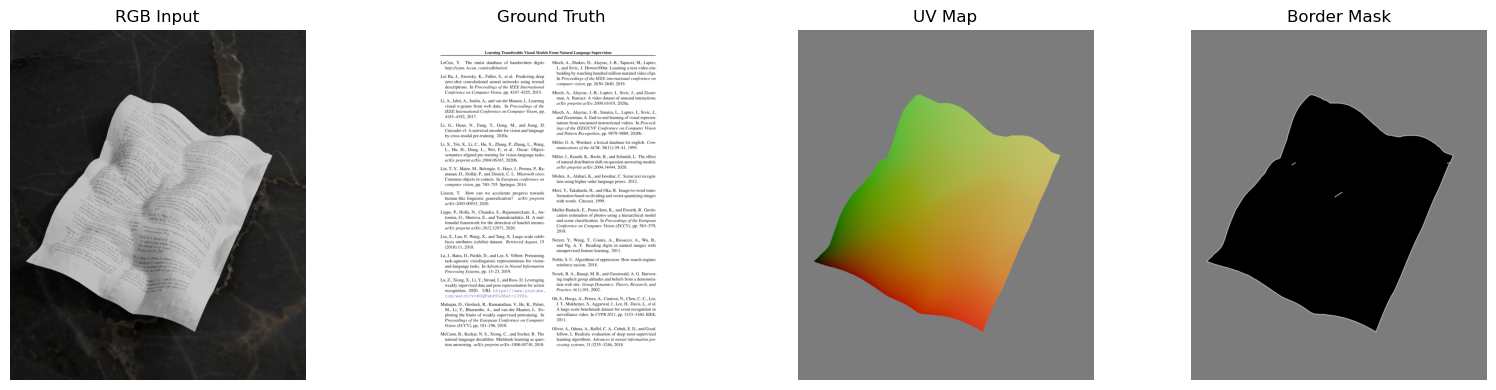

RGB size: (1080, 1280)
Ground truth size: (1224, 1584)
UV size: (1080, 1280)
Border size: (1080, 1280)


In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

data_dir = 'renders/synthetic_data_pitch_sweep'
base_name = 'Gemini_Generated_Image_ea83igea83igea83_paper_Final Project-44_P3_R0_A09'

rgb = Image.open(os.path.join(data_dir, 'rgb', base_name + '.jpg'))
gt = Image.open(os.path.join(data_dir, 'ground_truth', base_name + '.png'))
uv = Image.open(os.path.join(data_dir, 'uv', base_name + '.png'))
border = Image.open(os.path.join(data_dir, 'border', base_name + '.png'))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes, [rgb, gt, uv, border], ['RGB Input', 'Ground Truth', 'UV Map', 'Border Mask']):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"RGB size: {rgb.size}")
print(f"Ground truth size: {gt.size}")
print(f"UV size: {uv.size}")
print(f"Border size: {border.size}")

In [3]:
import numpy as np

border_arr = np.array(border)
print(f"Border dtype: {border_arr.dtype}")
print(f"Unique values: {np.unique(border_arr)}")
print(f"Min: {border_arr.min()}, Max: {border_arr.max()}")

Border dtype: uint8
Unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197]
Min: 0, Max: 197


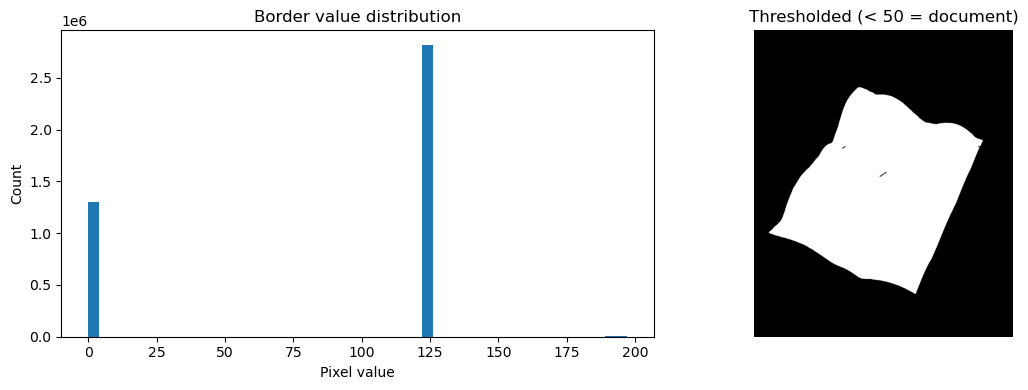

In [4]:
import numpy as np
import matplotlib.pyplot as plt

border_arr = np.array(border)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(border_arr.flatten(), bins=50)
plt.title('Border value distribution')
plt.xlabel('Pixel value')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
# Threshold to see what a binary version looks like
binary = (border_arr < 50).astype(np.uint8) * 255
plt.imshow(binary, cmap='gray')
plt.title('Thresholded (< 50 = document)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Sanity check for model 2

In [2]:
from model import *

/Users/michaelbehrens/micromamba/envs/cs135_25f_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = 'cpu'

In [5]:
model = DocumentDewarpNet().to(device)
dummy = torch.randn(2, 3, 512, 512).to(device)
rectified, flow = model(dummy)
print(f"Input shape: {dummy.shape}")
print(f"Rectified shape: {rectified.shape}")
print(f"Flow shape: {flow.shape}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Input shape: torch.Size([2, 3, 512, 512])
Rectified shape: torch.Size([2, 3, 512, 512])
Flow shape: torch.Size([2, 2, 512, 512])
Model parameters: 40,743,010


In [2]:
from PIL import Image
import numpy as np

img = Image.open('renders/synthetic_data_pitch_sweep/rgb/Gemini_Generated_Image_9etyf49etyf49ety_paper_Final Project-01_P1_R0_A06.jpg')
arr = np.array(img)
print(f"Shape: {arr.shape}")
print(f"Dtype: {arr.dtype}")
print(f"Min: {arr.min()}, Max: {arr.max()}")

Shape: (1280, 1080, 3)
Dtype: uint8
Min: 0, Max: 212


Shape: (1280, 1080, 3)
Dtype: uint8
Min: 0, Max: 219


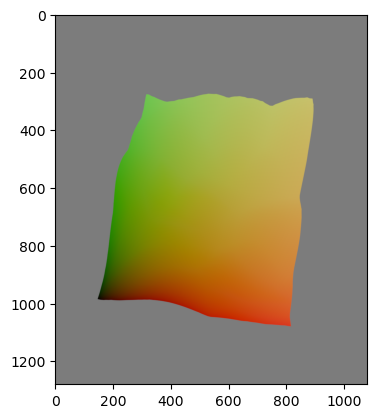

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uv_path = 'renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_9etyf49etyf49ety_paper_Final Project-01_P1_R0_A06.png'
uv_raw = Image.open(uv_path)
uv_arr = np.array(uv_raw)
print(f"Shape: {uv_arr.shape}")
print(f"Dtype: {uv_arr.dtype}")
print(f"Min: {uv_arr.min()}, Max: {uv_arr.max()}")
plt.imshow(uv_arr)
plt.show()